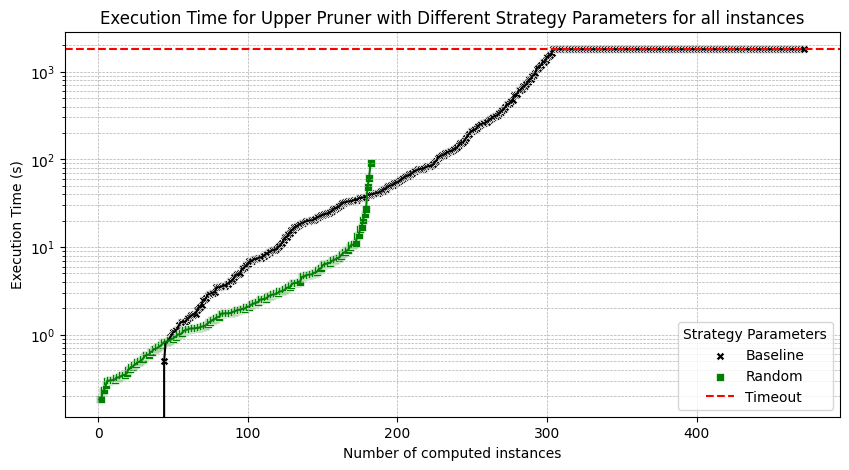

In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

# Drop all existing dataframes
for name in dir():
    if isinstance(eval(name), pd.core.frame.DataFrame):
        del globals()[name]

# Run garbage collection to free up memory
gc.collect()

# Load the CSV files into new Pandas DataFrames
baseline_file = '240730_Baseline.csv'  # Replace with your file path
df_baseline_new = pd.read_csv(baseline_file, delimiter=';', quotechar='"')

ARG_file = '240730_RESALL_ARG.csv'  # Replace with your file path
df_ARG_new = pd.read_csv(ARG_file, delimiter=';', quotechar='"')

SIG3_file = '240730_RESALL_SIG3.csv'  # Replace with your file path
df_SIG3_new = pd.read_csv(SIG3_file, delimiter=';', quotechar='"')

SIG5_file = '240730_RESALL_SIG5.csv'  # Replace with your file path
df_SIG5_new = pd.read_csv(SIG5_file, delimiter=';', quotechar='"')

SIG10_file = '240730_RESALL_SIG10.csv'  # Replace with your file path
df_SIG10_new = pd.read_csv(SIG10_file, delimiter=';', quotechar='"')

# Drop duplicate rows based on the filename column to ensure uniqueness
df_baseline_new = df_baseline_new.drop_duplicates(subset=['filename'])
df_ARG_new = df_ARG_new.drop_duplicates(subset=['filename'])
df_SIG3_new = df_SIG3_new.drop_duplicates(subset=['filename'])
df_SIG5_new = df_SIG5_new.drop_duplicates(subset=['filename'])
df_SIG10_new = df_SIG10_new.drop_duplicates(subset=['filename'])

# Fill missing values in strategy_param and execution_time columns
df_ARG_new['strategy_param'] = df_ARG_new['strategy_param'].fillna(0).astype(int)
df_ARG_new['execution_time'] = df_ARG_new['execution_time'].fillna(df_baseline_new['execution_time'])

df_SIG3_new['strategy_param'] = df_SIG3_new['strategy_param'].fillna(0).astype(int)
df_SIG3_new['execution_time'] = df_SIG3_new['execution_time'].fillna(df_baseline_new['execution_time'])

df_SIG5_new['strategy_param'] = df_SIG5_new['strategy_param'].fillna(0).astype(int)
df_SIG5_new['execution_time'] = df_SIG5_new['execution_time'].fillna(df_baseline_new['execution_time'])

df_SIG10_new['strategy_param'] = df_SIG10_new['strategy_param'].fillna(0).astype(int)
df_SIG10_new['execution_time'] = df_SIG10_new['execution_time'].fillna(df_baseline_new['execution_time'])

# Merge the dataframes on the filename column
df_combined = pd.merge(df_baseline_new, df_ARG_new, on='filename', suffixes=('_baseline', '_arg'), how='outer')
df_combined = pd.merge(df_combined, df_SIG3_new, on='filename', suffixes=('', '_sig3'), how='outer')
df_combined = pd.merge(df_combined, df_SIG5_new, on='filename', suffixes=('', '_sig5'), how='outer')
df_combined = pd.merge(df_combined, df_SIG10_new, on='filename', suffixes=('', '_sig10'), how='outer')

# Ensure we only have unique rows based on 'filename', 'strategy_param', and 'pruner'
df_combined = df_combined.drop_duplicates(subset=['filename', 'strategy_param', 'pruner'])

# Fill missing values in the strategy_param and execution_time columns for baseline data
df_combined['strategy_param'] = df_combined['strategy_param'].fillna(0).astype(int)
df_combined['execution_time'] = df_combined['execution_time'].fillna(df_combined['execution_time_baseline'])

# Create a mapping for the strategy parameters to different markers and colors
markers = {1: 'o', 2: 's', 3: '^', 0: 'X'}  # Define your strategy parameter markers
palette = {1: 'orange', 2: 'green', 3: 'blue', 0: 'black'}  # Define your strategy parameter colors
labels = {1: 'Cardinality', 2: 'Random', 3: 'Inconsistency', 0: 'Baseline'}  # Custom labels

plt.figure(figsize=(10, 5))

# Plot the baseline separately to ensure it is only plotted once
baseline_subset = df_combined[df_combined['strategy_param'] == 0]
if not baseline_subset.empty:
    baseline_subset = baseline_subset.sort_values(by='execution_time')
    baseline_subset['counter'] = range(1, len(baseline_subset) + 1)
    sns.scatterplot(
        x='counter', 
        y='execution_time', 
        data=baseline_subset,
        marker=markers[0], 
        color=palette[0], 
        label=labels[0]  # Use custom labels
    )
    plt.plot(
        baseline_subset['counter'], 
        baseline_subset['execution_time'], 
        linestyle='-', 
        color=palette[0]
    )

# Plot each strategy parameter separately to apply different markers and colors
for strategy_param, marker in markers.items():
    if strategy_param != 0:  # Skip baseline as it's already plotted
        subset = df_combined[df_combined['strategy_param'] == strategy_param]
        if not subset.empty:
            # Sort the subset by execution_time
            subset = subset.sort_values(by='execution_time')
            # Create a counter for the x-axis based on the sorted order
            subset['counter'] = range(1, len(subset) + 1)

            # Plot the scatter points
            sns.scatterplot(
                x='counter',
                y='execution_time',
                data=subset,
                marker=marker,
                color=palette[strategy_param],
                label=labels[strategy_param]  # Use custom labels
            )

            # Plot the lines connecting the points
            plt.plot(
                subset['counter'],
                subset['execution_time'],
                linestyle='-',
                color=palette[strategy_param]
            )

# Add a horizontal line for the timeout threshold (if applicable)
timeout_threshold = 1800  # Adjust this threshold as needed
plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')

# Customize the plot
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Execution Time for Upper Pruner with Different Strategy Parameters for all instances')
plt.xlabel('Number of computed instances')
plt.ylabel('Execution Time (s)')
plt.legend(title='Strategy Parameters')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('exe_time_allpruners_all.png', dpi=300, bbox_inches='tight')
plt.show()
